## ① Install Dependencies

In [ ]:
!pip install openpyxl statsmodels tabulate --quiet
print("✅ Dependencies ready")

✅ Dependencies ready


## ② Load Data & Define Column References
> Upload `Dataset.xlsx` to `/content/` before running this cell.

In [ ]:
import pandas as pd, numpy as np, sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy import stats

SEED = 42
np.random.seed(SEED)

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_excel('/content/Dataset (1).xlsx')
print(f"✅ Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# ── Exact TPB column names (verified from original notebook) ─────────────────
ATTD = [
    "ATTD1: Advertisements on social media can help me to be aware of the existence of a particular product.",
    "ATTD2: Advertisements on social media attract my attention more easily than that of other advertising channels, such as, television, etc.",
    'ATTD3: Prominent keywords, such as, "promotion" and "discount" on social media attract my attention to seek more information about a product.',
    "ATTD4:  I have purchased products advertised on social media."
]
SN = [
    "SN1: My family has influence over my purchasing habits through social media marketing.",
    "SN2: People around me think that I should purchase products through social media.",
    "SN3: I feel good if many people purchased products through social media.",
    "SN4: My friends encourage me to purchase products through social media."
]
PBC = [
    "PBC1: Frequent advertisement of a product on social media often motivates me to purchase it.",
    "PBC2: I will choose social media as a reference channel for purchasing in the future.",
    "PBC3: I will recommend social media channels to my friends to make purchasing decisions.",
    "PBC4: I will recommend social media channels to my family members to make purchasing decisions."
]
ALL_TPB = ATTD + SN + PBC
SHORT    = ['ATTD1','ATTD2','ATTD3','ATTD4','SN1','SN2','SN3','SN4','PBC1','PBC2','PBC3','PBC4']

# ── Verify columns exist ──────────────────────────────────────────────────────
missing_cols = [c for c in ALL_TPB if c not in df.columns]
if missing_cols:
    print("⚠️  These TPB columns were NOT found — check spelling:")
    for c in missing_cols: print(f"   {c}")
else:
    print(f"✅ All 12 TPB columns found")
    print(f"   ATTD: {[c[:6] for c in ATTD]}")
    print(f"   SN  : {[c[:4] for c in SN]}")
    print(f"   PBC : {[c[:5] for c in PBC]}")

# ── Environment info ──────────────────────────────────────────────────────────
import sklearn, scipy, matplotlib, seaborn
print(f"\n{'─'*45}")
print("Computational Environment")
print(f"{'─'*45}")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  scipy       : {scipy.__version__}")
print(f"  matplotlib  : {matplotlib.__version__}")
print(f"  seaborn     : {seaborn.__version__}")
print(f"{'─'*45}")
print(f"  Random seed : {SEED}")
print(f"  Normalizer  : StandardScaler (z-score)")
print(f"  KMeans init : k-means++, n_init=10, max_iter=300")

✅ Loaded: 266 rows × 29 columns
✅ All 12 TPB columns found
   ATTD: ['ATTD1:', 'ATTD2:', 'ATTD3:', 'ATTD4:']
   SN  : ['SN1:', 'SN2:', 'SN3:', 'SN4:']
   PBC : ['PBC1:', 'PBC2:', 'PBC3:', 'PBC4:']

─────────────────────────────────────────────
Computational Environment
─────────────────────────────────────────────
  Python      : 3.12.12
  pandas      : 2.2.2
  numpy       : 2.0.2
  scikit-learn: 1.6.1
  scipy       : 1.16.3
  matplotlib  : 3.10.0
  seaborn     : 0.13.2
─────────────────────────────────────────────
  Random seed : 42
  Normalizer  : StandardScaler (z-score)
  KMeans init : k-means++, n_init=10, max_iter=300


---
## ③ Demographic Profile → **Manuscript Tables 2 & 3**

In [ ]:
# ── TABLE 2: Full demographic breakdown ──────────────────────────────────────
demo_cols = {
    'Gender'    : 'Gender',
    'Age'       : 'Age',
    'Division'  : 'Division in Bangladesh you are based in:',
    'Occupation': 'Occupation:',
    'Income'    : 'Monthly income range:'
}

print("═"*60)
print("TABLE 2: Demographic Profile of Respondents  (N =", len(df), ")")
print("═"*60)
for label, col in demo_cols.items():
    if col not in df.columns:
        print(f"  [{label}] column not found: '{col}'"); continue
    vc  = df[col].value_counts()
    pct = df[col].value_counts(normalize=True)*100
    print(f"\n  {label}:")
    print(f"  {'Category':<35} {'n':>4}   {'%':>6}")
    print(f"  {'─'*48}")
    for cat in vc.index:
        print(f"  {str(cat):<35} {vc[cat]:>4}   {pct[cat]:>5.2f}%")

# ── TABLE 3: Gender-wise social media activity & purchase frequency ───────────
sm_col  = 'How active are you on social media?'
pur_col = 'How frequently do you engage in purchasing various items across different types on social media platforms?'
g_col   = 'Gender'

print("\n" + "═"*60)
print("TABLE 3: Gender-Wise Social Media Activity & Purchase Frequency")
print("═"*60)
if all(c in df.columns for c in [sm_col, pur_col, g_col]):
    t3 = df.groupby(g_col).agg(
        N               = (sm_col, 'count'),
        SM_Activity_Avg = (sm_col, 'mean'),
        Purchase_Freq_Avg=(pur_col,'mean')
    ).round(3)
    print(t3.to_string())
else:
    print("  ⚠️  One or more columns not found — check column names")

════════════════════════════════════════════════════════════
TABLE 2: Demographic Profile of Respondents  (N = 266 )
════════════════════════════════════════════════════════════

  Gender:
  Category                               n        %
  ────────────────────────────────────────────────
  Male                                 170   63.91%
  Female                                95   35.71%
  Prefer Not to Say                      1    0.38%

  Age:
  Category                               n        %
  ────────────────────────────────────────────────
  22                                    53   19.92%
  21                                    47   17.67%
  24                                    38   14.29%
  23                                    27   10.15%
  20                                    21    7.89%
  25                                    18    6.77%
  19                                    13    4.89%
  27                                     8    3.01%
  26                     

---
## ④ Data Preprocessing & Normalization
*Extracts the 12 TPB items, checks for missing values, and applies z-score standardization.*

In [ ]:
# ── Extract TPB subset ────────────────────────────────────────────────────────
df_tpb = df[ALL_TPB].copy()
print(f"Missing values in TPB columns : {df_tpb.isnull().sum().sum()}")
print(f"Duplicate rows in full dataset: {df.duplicated().sum()}")
df_tpb = df_tpb.dropna()
print(f"TPB subset after dropna       : {df_tpb.shape[0]} rows × {df_tpb.shape[1]} cols")

# ── Z-score standardization ───────────────────────────────────────────────────
scaler      = StandardScaler()
data_scaled = scaler.fit_transform(df_tpb)
print(f"\nAfter scaling → mean ≈ {data_scaled.mean():.4f},  std ≈ {data_scaled.std():.4f}")
print("Method: StandardScaler (zero mean, unit variance) — ensures no item dominates clustering")

df_scaled = pd.DataFrame(data_scaled, columns=SHORT, index=df_tpb.index)
print(f"✅ Ready for analysis: {df_scaled.shape}")

Missing values in TPB columns : 0
Duplicate rows in full dataset: 0
TPB subset after dropna       : 266 rows × 12 cols

After scaling → mean ≈ -0.0000,  std ≈ 1.0000
Method: StandardScaler (zero mean, unit variance) — ensures no item dominates clustering
✅ Ready for analysis: (266, 12)


---
## ⑤ Psychometric Validation: Cronbach's Alpha → **Manuscript Table 5**

Validates internal consistency of each TPB sub-scale **before** using items as clustering inputs.  
Threshold: **α ≥ 0.70** (Nunnally, 1978). *Added in response to Reviewer 1.*

In [ ]:
def cronbach_alpha(df_items):
    """Cronbach's Alpha for a DataFrame of Likert items."""
    items = df_items.dropna()
    k = items.shape[1]
    item_var  = items.var(axis=0, ddof=1).sum()
    total_var = items.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

def interp(a):
    if a >= 0.90: return "Excellent  ✓"
    if a >= 0.80: return "Good       ✓"
    if a >= 0.70: return "Acceptable ✓"
    if a >= 0.60: return "Questionable"
    return "Poor ✗"

a_attd = cronbach_alpha(df[ATTD])
a_sn   = cronbach_alpha(df[SN])
a_pbc  = cronbach_alpha(df[PBC])

print("═"*65)
print("TABLE 5: Reliability Analysis — Cronbach's Alpha for TPB Sub-Scales")
print("═"*65)
print(f"  {'Construct':<38}  {'Items':>5}  {'α':>6}  Interpretation")
print(f"  {'─'*61}")
for name, a in [("Attitude (ATTD)", a_attd),
                ("Subjective Norms (SN)", a_sn),
                ("Perceived Behavioral Control (PBC)", a_pbc)]:
    print(f"  {name:<38}  {4:>5}  {a:>6.3f}  {interp(a)}")
print(f"  {'─'*61}")
print(f"  Threshold: α ≥ 0.70 = Acceptable  (Nunnally, 1978)")

# Store for summary cell
alpha_results = dict(ATTD=a_attd, SN=a_sn, PBC=a_pbc)

═════════════════════════════════════════════════════════════════
TABLE 5: Reliability Analysis — Cronbach's Alpha for TPB Sub-Scales
═════════════════════════════════════════════════════════════════
  Construct                               Items       α  Interpretation
  ─────────────────────────────────────────────────────────────
  Attitude (ATTD)                             4   0.755  Acceptable ✓
  Subjective Norms (SN)                       4   0.721  Acceptable ✓
  Perceived Behavioral Control (PBC)          4   0.753  Acceptable ✓
  ─────────────────────────────────────────────────────────────
  Threshold: α ≥ 0.70 = Acceptable  (Nunnally, 1978)


---
## ⑥ Descriptive Statistics of TPB Constructs → **Manuscript Table 7**

In [ ]:
print("═"*72)
print("TABLE 7: Descriptive Statistics for TPB Items  (N =", len(df), ")")
print("═"*72)
print(f"  {'Item':<7}  {'Mean':>6}  {'Median':>6}  {'SD':>6}  {'Min':>4}  {'Max':>4}  {'Neutral %':>10}")
print(f"  {'─'*60}")

desc_rows = []
for short, col in zip(SHORT, ALL_TPB):
    s   = df[col].dropna()
    m   = s.mean(); med = s.median(); sd = s.std()
    mn  = s.min(); mx  = s.max()
    neu = (s == 3).sum() / len(s) * 100
    print(f"  {short:<7}  {m:>6.3f}  {med:>6.1f}  {sd:>6.3f}  {mn:>4.0f}  {mx:>4.0f}  {neu:>9.1f}%")
    desc_rows.append(dict(Item=short, Mean=round(m,3), Median=med, SD=round(sd,3), Neutral_pct=round(neu,1)))

print(f"  {'─'*60}")
print("\n  CONSTRUCT-LEVEL SUMMARY:")
for label, cols in [("ATTD", ATTD), ("SN", SN), ("PBC", PBC)]:
    v = df[cols].values.flatten(); v = v[~np.isnan(v)]
    print(f"  {label}: Mean={v.mean():.3f}  SD={v.std():.3f}  "
          f"Neutral={(v==3).sum()/len(v)*100:.1f}%")

desc_df = pd.DataFrame(desc_rows)   # stored for summary cell

════════════════════════════════════════════════════════════════════════
TABLE 7: Descriptive Statistics for TPB Items  (N = 266 )
════════════════════════════════════════════════════════════════════════
  Item       Mean  Median      SD   Min   Max   Neutral %
  ────────────────────────────────────────────────────────────
  ATTD1     3.673     4.0   0.937     1     5       28.2%
  ATTD2     3.635     4.0   0.990     1     5       28.6%
  ATTD3     3.590     4.0   1.025     1     5       30.5%
  ATTD4     3.462     4.0   1.089     1     5       30.5%
  SN1       2.598     2.0   1.139     1     5       26.7%
  SN2       2.876     3.0   1.022     1     5       40.6%
  SN3       3.023     3.0   0.931     1     5       50.8%
  SN4       3.019     3.0   1.048     1     5       35.7%
  PBC1      2.929     3.0   1.077     1     5       33.5%
  PBC2      3.289     3.0   0.945     1     5       41.0%
  PBC3      3.244     3.0   0.934     1     5       42.1%
  PBC4      3.124     3.0   0.969    

---
## ⑦ Multi-Criterion Cluster Validation → **Manuscript Table 6**

Four complementary indices assessed for k = 2 to 8.  
*Added in response to Reviewer 2 — moves beyond elbow-only validation.*

| Index | Direction | What it measures |
|---|---|---|
| WCSS (Elbow) | ↓ lower = better | Within-cluster compactness |
| Silhouette Score | ↑ higher = better | Cohesion vs separation (−1 to 1) |
| Davies-Bouldin Index | ↓ lower = better | Average cluster overlap |
| Calinski-Harabasz Index | ↑ higher = better | Between vs within-cluster dispersion |

════════════════════════════════════════════════════════════════════════════
TABLE 6: Cluster Validation Metrics  (k = 2 to 8)
════════════════════════════════════════════════════════════════════════════
   k      WCSS ↓    Silhouette ↑    Davies-Bouldin ↓    Calinski-Harabasz ↑
  ────────────────────────────────────────────────────────────────────────
   2     2375.47          0.2137              1.6070                  90.75
   3     2106.80          0.1494              1.8012                  67.74  ← k=3 SELECTED
   4     1957.65          0.1322              2.0986                  55.07
   5     1833.52          0.1234              1.9670                  48.34
   6     1765.35          0.1103              2.1930                  42.02
   7     1695.23          0.1209              2.0241                  38.11
   8     1653.33          0.1062              2.0761                  34.30
  ────────────────────────────────────────────────────────────────────────
  ↑ = higher is better

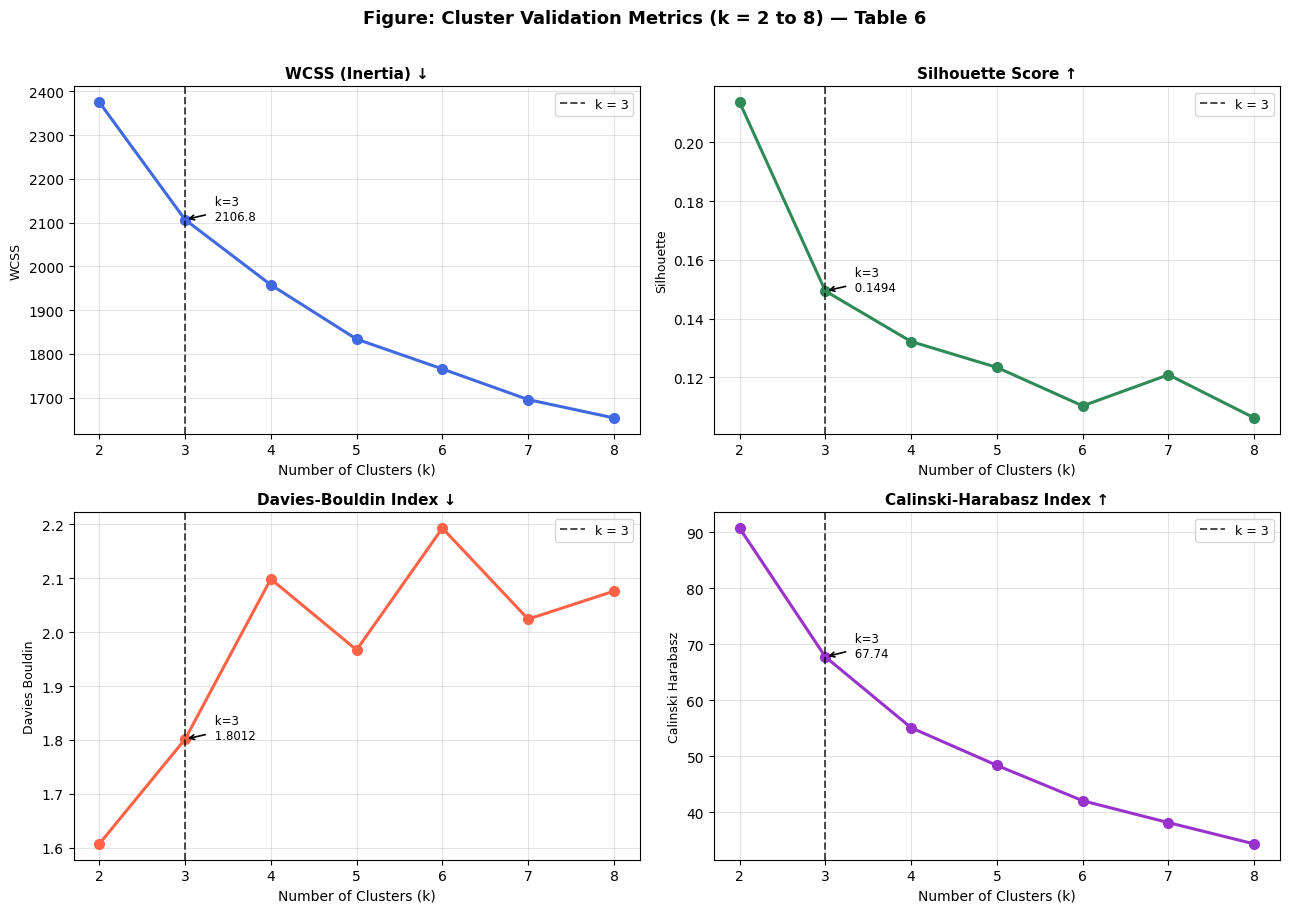


✅ Figure saved: table6_validation_metrics.png


In [ ]:
results = []
for k in range(2, 9):
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300, init='k-means++')
    labels = km.fit_predict(data_scaled)
    results.append({
        'k'  : k,
        'WCSS': round(km.inertia_, 2),
        'Silhouette'       : round(silhouette_score(data_scaled, labels), 4),
        'Davies_Bouldin'   : round(davies_bouldin_score(data_scaled, labels), 4),
        'Calinski_Harabasz': round(calinski_harabasz_score(data_scaled, labels), 2)
    })

val_df = pd.DataFrame(results)

print("═"*76)
print("TABLE 6: Cluster Validation Metrics  (k = 2 to 8)")
print("═"*76)
print(f"  {'k':>2}  {'WCSS ↓':>10}  {'Silhouette ↑':>14}  {'Davies-Bouldin ↓':>18}  {'Calinski-Harabasz ↑':>21}")
print(f"  {'─'*72}")
for _, row in val_df.iterrows():
    tag = "  ← k=3 SELECTED" if row['k'] == 3 else ""
    print(f"  {int(row.k):>2}  {row.WCSS:>10.2f}  {row.Silhouette:>14.4f}  "
          f"{row.Davies_Bouldin:>18.4f}  {row.Calinski_Harabasz:>21.2f}{tag}")
print(f"  {'─'*72}")
print("  ↑ = higher is better   ↓ = lower is better")

# ── 2×2 validation plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = [
    ('WCSS',              'WCSS (Inertia) ↓',          'royalblue'),
    ('Silhouette',        'Silhouette Score ↑',          'seagreen'),
    ('Davies_Bouldin',    'Davies-Bouldin Index ↓',      'tomato'),
    ('Calinski_Harabasz', 'Calinski-Harabasz Index ↑',   'darkorchid'),
]
for ax, (col, title, color) in zip(axes.flatten(), metrics):
    ax.plot(val_df['k'], val_df[col], 'o-', color=color, linewidth=2.2, markersize=7)
    ax.axvline(x=3, color='black', linestyle='--', linewidth=1.4, alpha=0.7, label='k = 3')
    v3 = val_df.loc[val_df['k']==3, col].values[0]
    ax.annotate(f' k=3\n {v3}', xy=(3, v3), xytext=(3.3, v3),
                fontsize=8.5, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)', fontsize=10)
    ax.set_ylabel(col.replace('_',' '), fontsize=9)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.35)

fig.suptitle('Figure: Cluster Validation Metrics (k = 2 to 8) — Table 6',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('table6_validation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Figure saved: table6_validation_metrics.png")

---
## ⑧ Final K-Means Clustering (k = 3) → **Figure 8**
*Parameters: k=3, random_state=42, n_init=10, max_iter=300, init='k-means++'*

K-Means Final Model  (k = 3)
  Inertia (WCSS) : 2106.7967
  Iterations     : 11

  Cluster        N       %  Label
  ──────────────────────────────────────────
  0            151   56.8%  Moderate Engagement
  1             56   21.1%  Low Engagement / Resistant
  2             59   22.2%  High Engagement


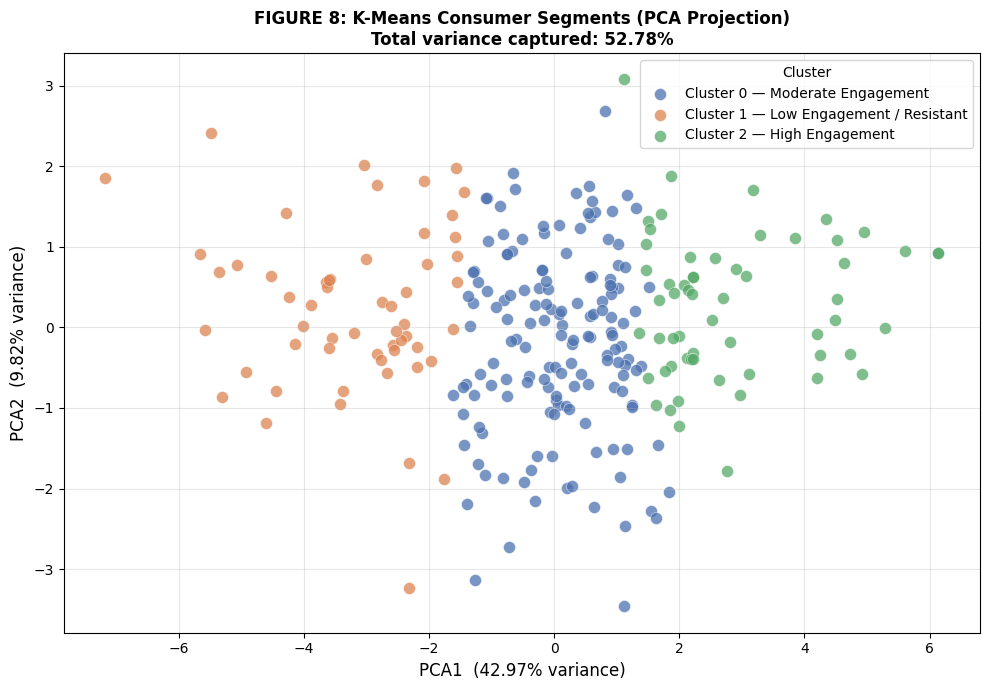


PCA Variance → PC1: 42.97%  |  PC2: 9.82%  |  Total: 52.78%
✅ Figure 8 saved: figure8_pca_clusters.png


In [ ]:
# ── Fit final model ───────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10, max_iter=300, init='k-means++')
cluster_labels = kmeans.fit_predict(data_scaled)
df.loc[df_tpb.index, 'Cluster'] = cluster_labels
df['Cluster'] = df['Cluster'].astype('Int64')

print("K-Means Final Model  (k = 3)")
print(f"  Inertia (WCSS) : {kmeans.inertia_:.4f}")
print(f"  Iterations     : {kmeans.n_iter_}")
print()
print(f"  {'Cluster':<10}  {'N':>4}  {'%':>6}  Label")
print(f"  {'─'*42}")
cluster_labels_map = {0:'Moderate Engagement', 1:'Low Engagement / Resistant', 2:'High Engagement'}
for c in [0, 1, 2]:
    n   = (df['Cluster'] == c).sum()
    pct = n / df['Cluster'].notna().sum() * 100
    print(f"  {c:<10}  {n:>4}  {pct:>5.1f}%  {cluster_labels_map[c]}")

# ── PCA 2-D visualization  (Figure 8) ────────────────────────────────────────
pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(data_scaled)
df.loc[df_tpb.index, 'PCA1'] = pca_coords[:, 0]
df.loc[df_tpb.index, 'PCA2'] = pca_coords[:, 1]

palette = {0:'#4C72B0', 1:'#DD8452', 2:'#55A868'}
fig, ax = plt.subplots(figsize=(10, 7))
df_plot = df[df['Cluster'].notna()].copy()
for c in [0, 1, 2]:
    mask = df_plot['Cluster'] == c
    ax.scatter(df_plot.loc[mask,'PCA1'], df_plot.loc[mask,'PCA2'],
               c=palette[c], label=f"Cluster {c} — {cluster_labels_map[c]}",
               s=75, alpha=0.75, edgecolors='white', linewidth=0.4)

ax.set_xlabel(f"PCA1  ({pca.explained_variance_ratio_[0]:.2%} variance)", fontsize=12)
ax.set_ylabel(f"PCA2  ({pca.explained_variance_ratio_[1]:.2%} variance)", fontsize=12)
ax.set_title(f"FIGURE 8: K-Means Consumer Segments (PCA Projection)\n"
             f"Total variance captured: {sum(pca.explained_variance_ratio_):.2%}",
             fontsize=12, fontweight='bold')
ax.legend(title='Cluster', fontsize=10, title_fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure8_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

pca_var = dict(PC1=round(pca.explained_variance_ratio_[0]*100,2),
               PC2=round(pca.explained_variance_ratio_[1]*100,2),
               Total=round(sum(pca.explained_variance_ratio_)*100,2))
print(f"\nPCA Variance → PC1: {pca_var['PC1']}%  |  PC2: {pca_var['PC2']}%  |  Total: {pca_var['Total']}%")
print("✅ Figure 8 saved: figure8_pca_clusters.png")

---
## ⑨ Cluster Characterization: Profiles & Demographics → **Manuscript Table 8**
*Added in response to Reviewer 2 — comprehensive cluster summary with means, SD, and demographics.*

═══════════════════════════════════════════════════════════════════════════════════════════════
TABLE 8: Cluster Characterization — TPB Construct Means, SD, and Demographics
═══════════════════════════════════════════════════════════════════════════════════════════════
  Cluster Label                           N      %      ATTD M(SD)        SN M(SD)       PBC M(SD)
  ───────────────────────────────────────────────────────────────────────────────────────────
  0    Moderate Engagement           151  56.8%  3.689(0.488)  2.813(0.485)  3.169(0.424)
  1    Low Engagement / Resistant     56  21.1%  2.576(0.593)  2.062(0.503)  2.201(0.485)
  2    High Engagement                59  22.2%  4.301(0.459)  3.822(0.521)  3.987(0.516)
  ───────────────────────────────────────────────────────────────────────────────────────────
  Scale 1–5 (Likert).  M = Mean,  SD = Standard Deviation

  Gender × Cluster:
Gender   Female  Male  Prefer Not to Say  All
Cluster                                      
0 

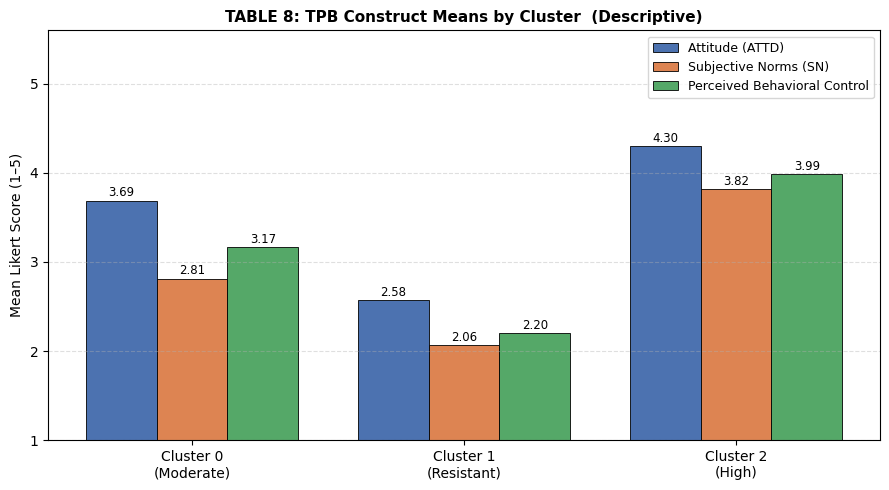

✅ Figure saved: table8_cluster_tpb_means.png


In [ ]:
# ── Construct means per respondent ───────────────────────────────────────────
df['ATTD_Mean'] = df[ATTD].mean(axis=1)
df['SN_Mean']   = df[SN].mean(axis=1)
df['PBC_Mean']  = df[PBC].mean(axis=1)

total_n = df['Cluster'].notna().sum()
summary = df.groupby('Cluster').agg(
    N         = ('Cluster','size'),
    ATTD_Mean = ('ATTD_Mean','mean'), ATTD_SD = ('ATTD_Mean','std'),
    SN_Mean   = ('SN_Mean','mean'),   SN_SD   = ('SN_Mean','std'),
    PBC_Mean  = ('PBC_Mean','mean'),  PBC_SD  = ('PBC_Mean','std'),
).reset_index()
summary['Pct'] = (summary['N'] / total_n * 100).round(1)

print("═"*95)
print("TABLE 8: Cluster Characterization — TPB Construct Means, SD, and Demographics")
print("═"*95)
print(f"  {'Cluster':<4} {'Label':<28} {'N':>4} {'%':>6}  "
      f"{'ATTD M(SD)':>14}  {'SN M(SD)':>14}  {'PBC M(SD)':>14}")
print(f"  {'─'*91}")
cluster_sum_rows = []
for _, r in summary.iterrows():
    lab = cluster_labels_map[int(r['Cluster'])]
    print(f"  {int(r.Cluster):<4} {lab:<28} {int(r.N):>4} {r.Pct:>5.1f}%"
          f"  {r.ATTD_Mean:>5.3f}({r.ATTD_SD:.3f})"
          f"  {r.SN_Mean:>5.3f}({r.SN_SD:.3f})"
          f"  {r.PBC_Mean:>5.3f}({r.PBC_SD:.3f})")
    cluster_sum_rows.append(r)

print(f"  {'─'*91}")
print("  Scale 1–5 (Likert).  M = Mean,  SD = Standard Deviation")

# ── Demographic cross-tabs ────────────────────────────────────────────────────
print("\n  Gender × Cluster:")
g_col = 'Gender'
if g_col in df.columns:
    print(pd.crosstab(df['Cluster'], df[g_col], margins=True).to_string())

occ_col = 'Occupation:'
if occ_col in df.columns:
    print("\n  Occupation × Cluster:")
    print(pd.crosstab(df['Cluster'], df[occ_col], margins=True).to_string())

# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3); w = 0.26
bars = [
    ax.bar(x-w,  summary['ATTD_Mean'], w, label='Attitude (ATTD)',             color='#4C72B0', edgecolor='black', linewidth=0.6),
    ax.bar(x,    summary['SN_Mean'],   w, label='Subjective Norms (SN)',        color='#DD8452', edgecolor='black', linewidth=0.6),
    ax.bar(x+w,  summary['PBC_Mean'],  w, label='Perceived Behavioral Control', color='#55A868', edgecolor='black', linewidth=0.6),
]
for bar_group in bars:
    for b in bar_group:
        ax.annotate(f'{b.get_height():.2f}',
                    xy=(b.get_x()+b.get_width()/2, b.get_height()),
                    xytext=(0,3), textcoords='offset points',
                    ha='center', fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(['Cluster 0\n(Moderate)', 'Cluster 1\n(Resistant)', 'Cluster 2\n(High)'], fontsize=10)
ax.set_ylabel('Mean Likert Score (1–5)', fontsize=10)
ax.set_ylim(1, 5.6)
ax.set_title('TABLE 8: TPB Construct Means by Cluster  (Descriptive)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('table8_cluster_tpb_means.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: table8_cluster_tpb_means.png")

---
## ⑩ Statistical Comparison: ANOVA + Post-Hoc Tests → **Manuscript Table 9**
*Added in response to Reviewer 2 — formal statistical testing of between-cluster differences.*

> ⚠️ **Important**: These tests confirm clusters are statistically distinct.  
> They do **not** establish causal relationships — the study remains exploratory.

In [ ]:
from scipy import stats
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    HAS_TUKEY = True
except ImportError:
    HAS_TUKEY = False
    print("statsmodels not available — using Bonferroni-corrected t-tests instead")

constructs = {
    'Attitude (ATTD)':                   'ATTD_Mean',
    'Subjective Norms (SN)':             'SN_Mean',
    'Perceived Behavioral Control (PBC)':'PBC_Mean'
}

anova_store = {}

print("═"*72)
print("TABLE 9: One-Way ANOVA — Cluster Differences on TPB Constructs")
print("═"*72)
print(f"  {'Construct':<42}  {'F-stat':>8}  {'p-value':>9}  Sig.")
print(f"  {'─'*68}")
for name, col in constructs.items():
    groups = [g[col].dropna().values for _, g in df.groupby('Cluster')]
    F, p   = stats.f_oneway(*groups)
    sig    = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f"  {name:<42}  {F:>8.3f}  {p:>9.5f}  {sig}")
    anova_store[name] = (round(F,3), round(p,5), sig)
print(f"  {'─'*68}")
print("  *** p<0.001   ** p<0.01   * p<0.05   ns = not significant")

# ── Post-hoc tests ────────────────────────────────────────────────────────────
print("\n" + "═"*72)
if HAS_TUKEY:
    print("TUKEY HSD POST-HOC PAIRWISE COMPARISONS")
    print("═"*72)
    for name, col in constructs.items():
        df_clean = df[['Cluster', col]].dropna()
        tukey    = pairwise_tukeyhsd(endog=df_clean[col],
                                     groups=df_clean['Cluster'], alpha=0.05)
        print(f"\n  {name}:")
        print(tukey.summary())
else:
    from itertools import combinations
    print("BONFERRONI-CORRECTED PAIRWISE t-TESTS  (statsmodels unavailable)")
    print("═"*72)
    pairs  = list(combinations([0,1,2], 2))
    n_comp = len(pairs)
    for name, col in constructs.items():
        print(f"\n  {name}:")
        for c1, c2 in pairs:
            g1 = df[df['Cluster']==c1][col].dropna()
            g2 = df[df['Cluster']==c2][col].dropna()
            t, p = stats.ttest_ind(g1, g2)
            p_adj = min(p * n_comp, 1.0)
            sig   = '***' if p_adj<0.001 else ('**' if p_adj<0.01 else ('*' if p_adj<0.05 else 'ns'))
            print(f"    Cluster {c1} vs Cluster {c2}: t={t:.3f},  p-adj={p_adj:.5f}  {sig}")

════════════════════════════════════════════════════════════════════════
TABLE 9: One-Way ANOVA — Cluster Differences on TPB Constructs
════════════════════════════════════════════════════════════════════════
  Construct                                     F-stat    p-value  Sig.
  ────────────────────────────────────────────────────────────────────
  Attitude (ATTD)                              173.573    0.00000  ***
  Subjective Norms (SN)                        183.182    0.00000  ***
  Perceived Behavioral Control (PBC)           218.436    0.00000  ***
  ────────────────────────────────────────────────────────────────────
  *** p<0.001   ** p<0.01   * p<0.05   ns = not significant

════════════════════════════════════════════════════════════════════════
TUKEY HSD POST-HOC PAIRWISE COMPARISONS
════════════════════════════════════════════════════════════════════════

  Attitude (ATTD):
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  

---
## ⑪ TPB Construct Contributions Across Clusters → **Table 10 + Figure 9**

══════════════════════════════════════════════════════════════════════════════
TABLE 10: Mean Standardized TPB Contributions by Cluster
(Positive = above-average endorsement within cluster; Negative = below-average)
══════════════════════════════════════════════════════════════════════════════
  Item             C0 (Moderate)           C1 (Low Enga)           C2 (High Eng)
  ──────────────────────────────────────────────────────────────────────────
  ATTD1    +0.102 (Weak+  )   -0.911 (Strong-)   +0.604 (Mod+   )
  ATTD2    +0.094 (Weak+  )   -1.023 (Strong-)   +0.729 (Mod+   )
  ATTD3    +0.083 (Weak+  )   -0.979 (Strong-)   +0.715 (Mod+   )
  ATTD4    +0.111 (Weak+  )   -1.099 (Strong-)   +0.760 (Mod+   )
  SN1      -0.083 (Weak-  )   -0.746 (Strong-)   +0.920 (Strong+)
  SN2      -0.132 (Weak-  )   -0.596 (Strong-)   +0.902 (Strong+)
  SN3      -0.024 (Weak-  )   -0.908 (Strong-)   +0.924 (Strong+)
  SN4      -0.012 (Weak-  )   -0.923 (Strong-)   +0.906 (Strong+)
  PBC1     +0.029 (

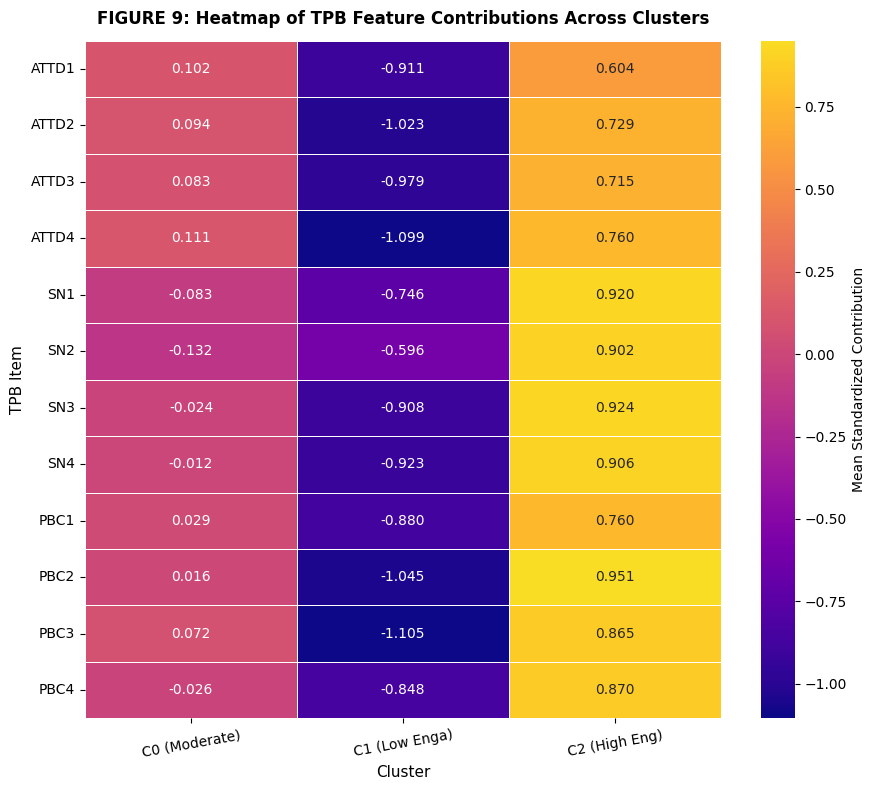

✅ Figure 9 saved: figure9_tpb_heatmap.png


In [ ]:
# ── Cluster-level means of STANDARDIZED features ─────────────────────────────
df_scaled_lab = df_scaled.copy()
df_scaled_lab['Cluster'] = cluster_labels
contrib = df_scaled_lab.groupby('Cluster')[SHORT].mean()
contrib.index = [f'C{i} ({cluster_labels_map[i][:8]})' for i in contrib.index]

def strength(v):
    if v >= 0.90: return "Strong+"
    if v >= 0.60: return "Mod+"
    if v >= 0.01: return "Weak+"
    if v >= -0.59: return "Weak-"
    return "Strong-"

print("═"*78)
print("TABLE 10: Mean Standardized TPB Contributions by Cluster")
print("(Positive = above-average endorsement within cluster; Negative = below-average)")
print("═"*78)
header = f"  {'Item':<6}" + "".join(f"  {c:>22}" for c in contrib.index)
print(header)
print(f"  {'─'*74}")
for item in SHORT:
    row = f"  {item:<6}"
    for idx in contrib.index:
        v = contrib.loc[idx, item]
        row += f"  {v:>+7.3f} ({strength(v):<7})"
    print(row)

# ── Heatmap (Figure 9) ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(contrib.T,
            annot=True, fmt='.3f',
            cmap='plasma',
            center=0,
            linewidths=0.4,
            cbar_kws={'label': 'Mean Standardized Contribution'},
            ax=ax)
ax.set_title('FIGURE 9: Heatmap of TPB Feature Contributions Across Clusters',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Cluster', fontsize=11); ax.set_ylabel('TPB Item', fontsize=11)
ax.tick_params(axis='x', rotation=10); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('figure9_tpb_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 9 saved: figure9_tpb_heatmap.png")

---
## ⑫ Behavioral Associations with TPB Dimensions → **Manuscript Table 11**
> All values are Pearson r — **descriptive associations only**, no causal interpretation.

════════════════════════════════════════════════════════════════════════════════════════
TABLE 11: Pearson Correlations — TPB Items vs Behavioral Variables
(All values are descriptive Pearson r; no causal interpretation)
════════════════════════════════════════════════════════════════════════════════════════
  Item      SM Activity Purchase Freq.   Income Spent   Internet Hrs Ratings Influence   Ad Influence
  ────────────────────────────────────────────────────────────────────────────────────
  ATTD1          +0.045         +0.054         +0.058         +0.168         +0.201         +0.140
  ATTD2          +0.072         +0.227         +0.141         +0.018         +0.183         +0.175
  ATTD3          +0.108         +0.149         +0.026         +0.059         +0.124         +0.154
  ATTD4          +0.211         +0.244         +0.226         +0.152         +0.185         +0.308
  SN1            +0.013         +0.169         -0.007         -0.020         +0.033         +0.101
  SN2 

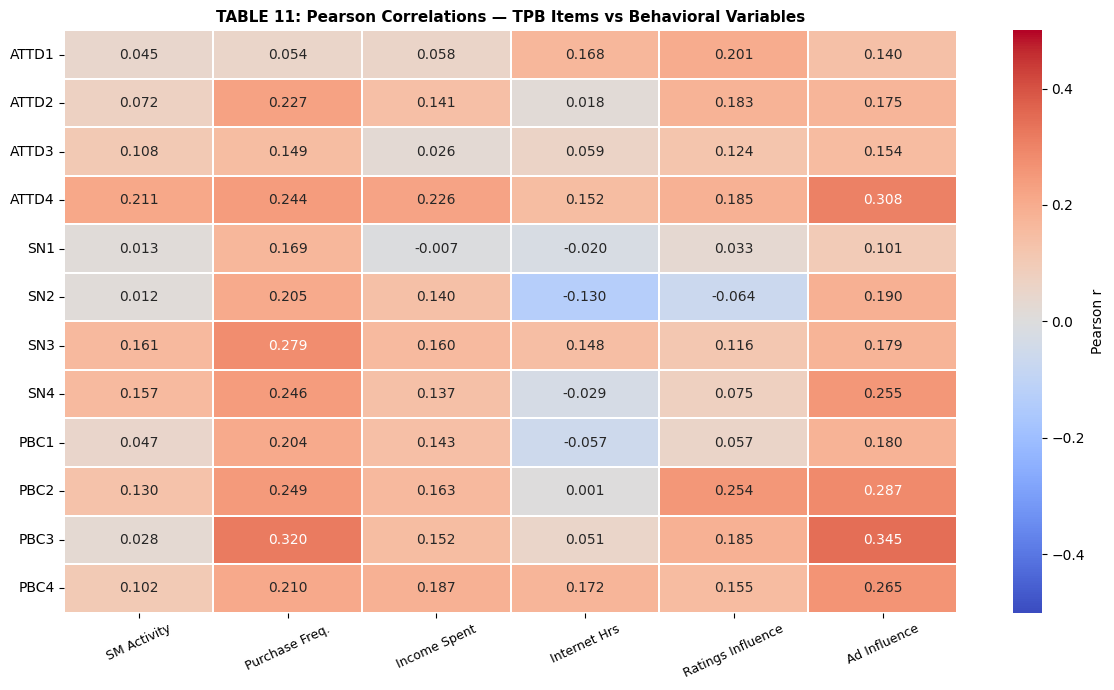

✅ Figure saved: table11_behavioral_correlations.png


In [ ]:
# ── Encode behavioral variables to numeric ───────────────────────────────────
def encode_inet(x):
    m = {'Less than 10 hours':5,'10 hours – 20 hours':15,'10 hours - 20 hours':15,
         '20 hours – 40 hours':30,'20 hours - 40 hours':30,'40 hours':40,'Above 40 hours':50}
    return m.get(str(x).strip(), np.nan)

def encode_3level(x):
    return {'Always':3,'Sometimes':2,'Never':1}.get(str(x).strip(), np.nan)

def encode_income_pct(x):
    try:
        x = str(x).replace('%','').strip()
        if '-' in x:
            # For ranges like '5-10%' calculate the midpoint
            a,b = x.split('-'); return (float(a)+float(b))/2
        if 'Less' in x or '<' in x:
            # Assign a lower bound for 'Less than X'
            return 2.5 # Assuming a reasonable low percentage
        if 'More' in x or '>' in x:
            # Assign an upper bound for 'More than X'
            return 35  # Assuming a reasonable high percentage
    except: pass
    return np.nan

# Column name constants (verified)
COL_SM_ACT  = 'How active are you on social media?'
COL_PUR_FRQ = 'How frequently do you engage in purchasing various items across different types on social media platforms?'
COL_INCOME  = 'How much of your monthly income you spend on purchases on social media?'
COL_INET    = 'On average, how many hours do you spend on the internet per week (out of 168 hours)?'
COL_RATINGS = 'Do the reviews and ratings influence your purchasing decision?'
COL_ADS     = df.columns[12]   # column index 13 (0-based = 12) — ad influence

# Build encoded series
df['_inet']   = df[COL_INET].apply(encode_inet)    if COL_INET   in df.columns else np.nan
df['_ratings']= df[COL_RATINGS].apply(encode_3level) if COL_RATINGS in df.columns else np.nan
df['_ads']    = df[COL_ADS].apply(encode_3level)
# Apply income encoding
df['_income_numeric'] = df[COL_INCOME].apply(encode_income_pct)

behav = {
    'SM Activity'      : COL_SM_ACT,
    'Purchase Freq.'   : COL_PUR_FRQ,
    'Income Spent'     : '_income_numeric', # Use the new numeric column
    'Internet Hrs'     : '_inet',
    'Ratings Influence': '_ratings',
    'Ad Influence'     : '_ads',
}

# ── Compute Pearson correlations ──────────────────────────────────────────────
corr_rows = {}
for blabel, bcol in behav.items():
    # Ensure bcol exists in df before proceeding
    if bcol not in df.columns:
        if bcol not in ['_inet', '_ratings', '_ads', '_income_numeric']:
            print(f"Warning: Column '{bcol}' not found in DataFrame. Skipping correlation for '{blabel}'.")
        continue

    row = {}
    for short, tcol in zip(SHORT, ALL_TPB):
        pair = pd.DataFrame({'b': df[bcol], 't': df[tcol]}).dropna()
        row[short] = round(pair['b'].corr(pair['t']), 3) if len(pair) > 10 else np.nan
    corr_rows[blabel] = row

corr_df = pd.DataFrame(corr_rows)

print("═"*88)
print("TABLE 11: Pearson Correlations — TPB Items vs Behavioral Variables")
print("(All values are descriptive Pearson r; no causal interpretation)")
print("═"*88)
print(f"  {'Item':<6}" + "".join(f" {c:>14}" for c in corr_df.columns))
print(f"  {'─'*84}")
for item in SHORT:
    row_str = f"  {item:<6}"
    for col in corr_df.columns:
        v = corr_df.loc[item, col]
        row_str += f" {v:>+14.3f}" if not np.isnan(v) else f" {'—':>14}"
    print(row_str)

# ── Correlation heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.3, vmin=-0.5, vmax=0.5,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('TABLE 11: Pearson Correlations — TPB Items vs Behavioral Variables',
             fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=25, labelsize=9)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('table11_behavioral_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: table11_behavioral_correlations.png")

---
## ⑬ Psychological Trait Mapping → **Manuscript Table 12**

In [ ]:
# Cluster-2 standardized mean values already in 'contrib' from Cell 11
# contrib rows are labelled — find Cluster 2 row
c2_row = [r for r in contrib.index if r.startswith('C2')][0]
c2 = contrib.loc[c2_row]

trait_items = [
    ("Trust",                "PBC2", PBC[1]),
    ("Convenience",          "PBC1", PBC[0]),
    ("Social Influence",     "SN3",  SN[2]),
    ("Social Influence",     "SN4",  SN[3]),
    ("Marketing Effectiveness","ATTD3",ATTD[2]),
    ("Marketing Effectiveness","ATTD4",ATTD[3]),
]

print("═"*82)
print("TABLE 12: Psychological Trait Mapping to TPB Constructs & Cluster Profiles")
print("═"*82)
print(f"  {'Trait':<28}  {'Item':<6}  {'Overall M':>10}  {'Overall SD':>11}  {'Cluster 2 Val':>14}")
print(f"  {'─'*78}")
for trait, short, col in trait_items:
    if col in df.columns:
        s   = df[col].dropna()
        m   = s.mean(); sd = s.std()
        c2v = c2.get(short, np.nan)
        print(f"  {trait:<28}  {short:<6}  {m:>10.3f}  {sd:>11.3f}  {c2v:>+14.3f}")
print(f"  {'─'*78}")
print("  'Cluster 2 Val' = standardized mean contribution for Cluster 2 (High Engagement)")
print("  Positive values = above-average endorsement in Cluster 2")
print()
print("  SYNTHESIS — Cluster 2 Psychological Profile:")
print("  • Trust         : Strong  — rely on SM as reference before purchasing")
print("  • Convenience   : High    — responsive to embedded, frictionless ads")
print("  • Social Inf.   : Strong  — peer validation drives collective purchasing")
print("  • Mktg. Effect  : Strong  — promotional keywords/ads convert to purchases")

══════════════════════════════════════════════════════════════════════════════════
TABLE 12: Psychological Trait Mapping to TPB Constructs & Cluster Profiles
══════════════════════════════════════════════════════════════════════════════════
  Trait                         Item     Overall M   Overall SD   Cluster 2 Val
  ──────────────────────────────────────────────────────────────────────────────
  Trust                         PBC2         3.289        0.945          +0.951
  Convenience                   PBC1         2.929        1.077          +0.760
  Social Influence              SN3          3.023        0.931          +0.924
  Social Influence              SN4          3.019        1.048          +0.906
  Marketing Effectiveness       ATTD3        3.590        1.025          +0.715
  Marketing Effectiveness       ATTD4        3.462        1.089          +0.760
  ──────────────────────────────────────────────────────────────────────────────
  'Cluster 2 Val' = standardized mean

---
## ⑭ Segment-Specific Marketing Strategy → **Manuscript Table 13**

In [ ]:
from IPython.display import display, HTML

html = """
<style>
  .ms { border-collapse:collapse; width:100%; font-family:Arial; font-size:13px; }
  .ms th { background:#2E75B6; color:white; padding:9px 12px; text-align:left; }
  .ms td { border:1px solid #ccc; padding:8px 12px; vertical-align:top; }
  .ms tr:nth-child(odd) td { background:#F7FBFF; }
  .c2 td { background:#E8F4E8 !important; font-weight:bold; }
</style>
<h3 style='font-family:Arial'>TABLE 13: Segment-Specific Strategic Recommendations</h3>
<table class='ms'>
  <tr>
    <th>Cluster</th><th>Profile</th><th>Key Psychological Driver</th>
    <th>Recommended Strategy</th><th>Priority Channel</th>
  </tr>
  <tr class='c2'>
    <td>Cluster 2</td>
    <td><b>High Engagement</b></td>
    <td>Trust + Peer Norms + Strong PBC</td>
    <td>Personalized promotions, influencer campaigns, loyalty rewards, exclusive offers, social proof</td>
    <td>Instagram, Facebook, TikTok</td>
  </tr>
  <tr>
    <td>Cluster 0</td>
    <td>Moderate Engagement</td>
    <td>Mild ATTD; indifferent to SN</td>
    <td>Functional messaging (quality, security, value), educational content, rational appeal</td>
    <td>Facebook, e-commerce platforms</td>
  </tr>
  <tr>
    <td>Cluster 1</td>
    <td>Low / Resistant</td>
    <td>High resistance across all TPB</td>
    <td>Long-term trust-building, offline reinforcement, localized education, simplified UX</td>
    <td>SMS, community groups, offline</td>
  </tr>
</table>
<p style='font-family:Arial;font-size:12px;color:#555'>
  <i>Cluster 2 = primary digital commerce target. Cluster 1 requires fundamentally different, trust-first engagement.</i>
</p>
"""
display(HTML(html))

Cluster,Profile,Key Psychological Driver,Recommended Strategy,Priority Channel
Cluster 2,High Engagement,Trust + Peer Norms + Strong PBC,"Personalized promotions, influencer campaigns, loyalty rewards, exclusive offers, social proof","Instagram, Facebook, TikTok"
Cluster 0,Moderate Engagement,Mild ATTD; indifferent to SN,"Functional messaging (quality, security, value), educational content, rational appeal","Facebook, e-commerce platforms"
Cluster 1,Low / Resistant,High resistance across all TPB,"Long-term trust-building, offline reinforcement, localized education, simplified UX","SMS, community groups, offline"


---
## ⑮ 📋 Complete Manuscript Values Summary
**Run this cell last** — it prints every number needed to fill the manuscript tables.

In [ ]:
print("╔" + "═"*68 + "╗")
print("║  COMPLETE MANUSCRIPT TABLE VALUES SUMMARY" + " "*26 + "║")
print("╚" + "═"*68 + "╝")

# Table 5 — Cronbach's Alpha
print("\n[TABLE 5]  Cronbach's Alpha")
print(f"  ATTD : α = {alpha_results['ATTD']:.3f}  →  {interp(alpha_results['ATTD'])}")
print(f"  SN   : α = {alpha_results['SN']:.3f}  →  {interp(alpha_results['SN'])}")
print(f"  PBC  : α = {alpha_results['PBC']:.3f}  →  {interp(alpha_results['PBC'])}")

# Table 6 — Validation metrics for k=3
print("\n[TABLE 6]  Cluster Validation at k = 3")
r3 = val_df[val_df['k']==3].iloc[0]
print(f"  WCSS               : {r3['WCSS']:.2f}")
print(f"  Silhouette Score   : {r3['Silhouette']:.4f}")
print(f"  Davies-Bouldin     : {r3['Davies_Bouldin']:.4f}")
print(f"  Calinski-Harabasz  : {r3['Calinski_Harabasz']:.2f}")

# Table 7 — Descriptive stats
print("\n[TABLE 7]  Descriptive Statistics (Mean / SD / Neutral %)")
for short, col in zip(SHORT, ALL_TPB):
    s = df[col].dropna()
    print(f"  {short:<5}: M = {s.mean():.3f},  SD = {s.std():.3f},  "
          f"Neutral = {(s==3).mean()*100:.1f}%")

# Table 8 — Cluster sizes and means
print("\n[TABLE 8]  Cluster Characterization")
for _, r in summary.iterrows():
    print(f"  Cluster {int(r.Cluster)}  N={int(r.N)} ({r.Pct:.1f}%)  "
          f"ATTD={r.ATTD_Mean:.3f}±{r.ATTD_SD:.3f}  "
          f"SN={r.SN_Mean:.3f}±{r.SN_SD:.3f}  "
          f"PBC={r.PBC_Mean:.3f}±{r.PBC_SD:.3f}")

# Table 9 — ANOVA
print("\n[TABLE 9]  ANOVA Results")
for name, (F, p, sig) in anova_store.items():
    print(f"  {name}: F = {F:.3f},  p = {p:.5f}  {sig}")

# Figure 8 — PCA variance
print("\n[FIGURE 8]  PCA Variance Explained")
print(f"  PC1 = {pca_var['PC1']}%  |  PC2 = {pca_var['PC2']}%  |  Total = {pca_var['Total']}%")

# Table 11 — Strongest correlations
print("\n[TABLE 11]  Top Behavioral Correlations (absolute r ≥ 0.25):")
flat = corr_df.stack().reset_index()
flat.columns=['Item','BehavVar','r']
flat = flat.dropna().reindex(flat['r'].abs().sort_values(ascending=False).index)
for _, row in flat[flat['r'].abs() >= 0.25].head(12).iterrows():
    print(f"  {row['Item']} × {row['BehavVar']}: r = {row['r']:+.3f}")

print("\n" + "═"*70)
print("All figures saved as PNG files in /content/")
print("═"*70)

╔════════════════════════════════════════════════════════════════════╗
║  COMPLETE MANUSCRIPT TABLE VALUES SUMMARY                          ║
╚════════════════════════════════════════════════════════════════════╝

[TABLE 5]  Cronbach's Alpha


NameError: name 'alpha_results' is not defined